## <center> École Polytechnique de Montréal <br> Département Génie Informatique et Génie Logiciel <br>  INF8245AE – Machine Learning <br> </center>
## <center> Compétition Kaggle - Détection de diabète <br> Automne 2024 </center>

## Identification de l'équipe: (◣_◢)

### Membres:
- Membres de l’´equipe: Adrien Wils, Augustin Cucchi et Elie Saleh
- E-mails: adrien.wils@polymtl.ca, augustin.cucchi@polymtl.ca et elie.saleh@polymtl.ca
- Matricules: 2403911, 2403527 et 240331

## Importation des librairies nécessaires au projet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.ensemble import (
    VotingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
)
from imblearn.under_sampling import RandomUnderSampler

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from copy import deepcopy

## Exploration des données

### Description des données

In [10]:
# Chargement des données
df_data_train = pd.read_csv("data/train.csv").drop(columns=["Unnamed: 0"])
df_labels_train = pd.read_csv("data/labels.csv").drop(columns=["Unnamed: 0"])

In [11]:
df_data_train.dtypes

HighBP                    int64
HighChol                  int64
CholCheck                 int64
BMI                     float64
Smoker                    int64
Stroke                    int64
HeartDiseaseorAttack      int64
PhysActivity              int64
Fruits                    int64
Veggies                   int64
HvyAlcoholConsump         int64
AnyHealthcare             int64
NoDocbcCost               int64
GenHlth                   int64
MentHlth                float64
PhysHlth                float64
DiffWalk                  int64
Sex                       int64
Age                     float64
Education               float64
Income                  float64
BMI_Category             object
Healthy_Diet              int64
Mental_Health_Risk        int64
Heart_Disease_Risk        int64
Age_Group                object
Education_Level          object
Income_Group             object
dtype: object

Le jeu de données comprend 28 colonnes avec divers types de données :
- Variables continues (float64) : `BMI`, `MentHlth`, `PhysHlth`, `Age`, `Education`, `Income`.
- Variables catégoriques (object) : `BMI_Category`, `Age_Group`, `Education_Level`, `Income_Group`.
- Variables binaires (int64) : Indicateurs de santé ou comportements, comme `HighBP`, `Smoker`, `Stroke`, `HeartDiseaseorAttack`, `PhysActivity`, `Healthy_Diet`, et des risques comme `Mental_Health_Risk` et `Heart_Disease_Risk`.

Ces variables couvrent des aspects démographiques, médicaux, comportementaux et socio-économiques.

In [12]:
print(f"Présence de valeur manquante : {not all(df_data_train.isna().sum())==0}")

Présence de valeur manquante : False


On ne détecte pas la présence de valeur manquante.

### Visualisation des données et de leur tendance

array([[<Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'Smoker'}>],
       [<Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>,
        <Axes: title={'center': 'Veggies'}>],
       [<Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>,
        <Axes: title={'center': 'MentHlth'}>],
       [<Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'Income'}>,
        <Axes: title={'center'

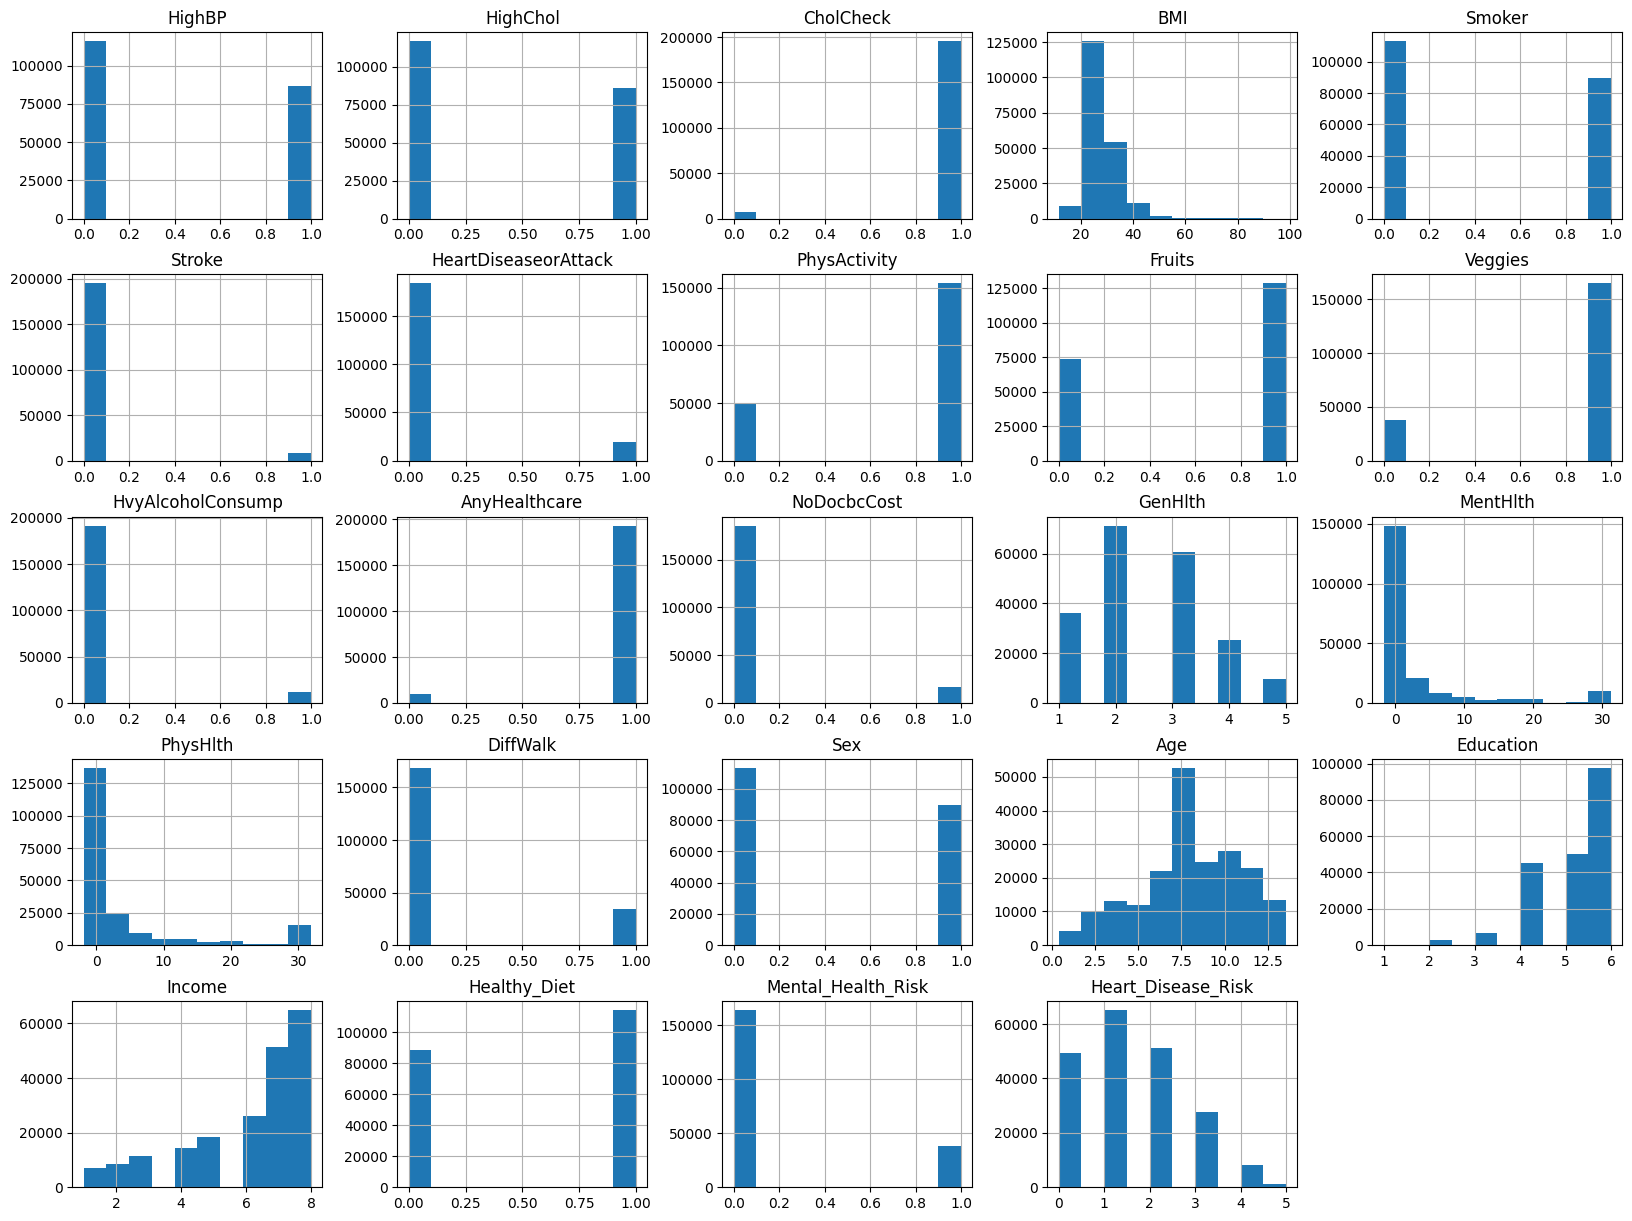

In [13]:
df_data_train.hist(figsize=(20,15))

On constate par cette historique, sur les données sans traitement, qu'une bonne partie des attributs sont de nature binaire et qu'ils traduisent d'une tendance de déséquilibre entre classe ce qui peut se voir encore plus facilement avec l'histogramme ci-dessous. Ainsi, si on reformule le problème suivant il s'agit avant tout de trouver un moyen pour correctement filtrer les données pour que les modèles ne soient pas induits par ce même biais. 

array([[<Axes: title={'center': 'Diabetes_binary'}>]], dtype=object)

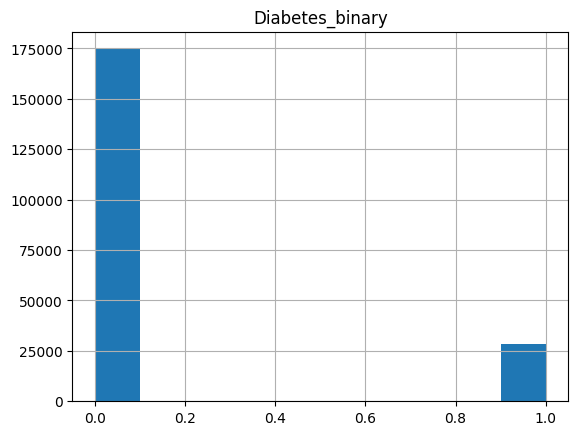

In [14]:
df_labels_train.hist()

## Prétraitement des données pour l'entraînement

Dans le but de prétraiter les données et correctement assigner des valeurs pour que les modèles comprennent la différence entre la classe d'intérêt (présence de diabète) et son complémentaire, nous avons décidé de procéder aux étapes de prétraitement suivant : 
- 2.1 Suppression des colonnes inutiles : Les colonnes redondantes ou sans valeur informative, comme Age Group et Unnamed: 0, sont supprimées.

- 2.2 Conversion des variables catégorielles en numériques : Les catégories ordonnées (BMI Category, Education Level, Income Group) sont mappées sur des valeurs numériques reflétant leur importance relative.

- 2.3 Fabrication de variables non-linéaires : Des termes polynomiaux de degré 2 sont ajoutés pour capturer des interactions complexes entre les caractéristiques continues.

- 2.4 Nettoyage des noms de colonnes : Les noms de colonnes sont nettoyés pour garantir leur compatibilité avec des frameworks comme LightGBM.

- 2.5 Traitement des valeurs manquantes : Aucune valeur manquante n'étant détectée, aucun traitement supplémentaire n'est nécessaire.

- 2.6 Découpage des données : Les données sont divisées en ensembles d’entraînement et de test avec une répartition stratifiée pour conserver le déséquilibre initial des classes.

- 2.7 Normalisation Z-score : Les caractéristiques sont normalisées pour avoir une moyenne de 0 et un écart-type de 1, en veillant à éviter toute fuite d’information entre les ensembles d'entraînement et de test.

- 2.8 Sous-échantillonage : Pour atténuer l'impact du déséquilibre des classes, nous avons appliqué un sous-échantillonnage aléatoire lors du prétraitement, réduisant ainsi l'écart numérique entre les deux classes. Par ailleurs, des mesures complémentaires ont été intégrées directement lors de la configuration des modèles.

In [15]:
# Fonction de prétraitement
def pretraitement(df_data_train, df_labels_train=None):
    df_data_train_copy = df_data_train.drop(["Age_Group"], axis=1)
    df_data_train_copy["BMI_Category"] = df_data_train_copy["BMI_Category"].map(
        {"Underweight": 0, "Normal weight": 1, "Overweight": 3, "Obese": 5}
    )
    df_data_train_copy["Education_Level"] = df_data_train_copy["Education_Level"].map(
        {"No High School": 0, "High School Graduate": 3, "Some College": 4}
    )
    df_data_train_copy["Income_Group"] = df_data_train_copy["Income_Group"].map(
        {"Low Income": 1, "Middle Income": 3, "High Income": 6}
    )

    # Polynomial features
    continuous_features = ["BMI", "MentHlth", "PhysHlth", "Age"]
    poly = PolynomialFeatures(degree=2, include_bias=False)
    poly_features = poly.fit_transform(df_data_train_copy[continuous_features])

    # Add polynomial features
    poly_feature_names = [
        f"{name}_poly2" if "^2" in name or " " in name else name
        for name in poly.get_feature_names_out(continuous_features)
    ]
    X_poly = pd.DataFrame(
        poly_features, columns=poly_feature_names, index=df_data_train_copy.index
    )
    df_data_train_copy = pd.concat(
        [df_data_train_copy, X_poly.loc[:, poly_feature_names[4:]]], axis=1
    )

    # Clean feature names for LightGBM compatibility
    df_data_train_copy.columns = df_data_train_copy.columns.str.replace(
        "[^A-Za-z0-9_]+", "", regex=True
    )
    df_data_train_copy.fillna(df_data_train_copy.median(), inplace=True)

    if df_labels_train is not None:
        df_labels_train_copy = df_labels_train
        return df_data_train_copy, df_labels_train_copy
    return df_data_train_copy


# Prétraitement
df_data_train_copy, df_labels_train_copy = pretraitement(df_data_train, df_labels_train)

# Split des données (ici le jeu de test joue le rôle de validation)
X_train, X_test, y_train, y_test = train_test_split(
    df_data_train_copy,
    df_labels_train_copy,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Undersampling
rus = RandomUnderSampler(sampling_strategy=0.19, random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

## Instanciation de modèles 

L'état de l'art de la détection de diabètes sont les modèles principalement basés sur la notion d'arbre de décision, ainsi nous nous sommes concentrés sur les modèles suivants :
- LightGBM
- XGBoost
- CatBoost
- HistGradientBoosting
- ExtraTrees 

### Etude de certains hyperparamètres pour chaque modèle

In [16]:
lgbm_clf = LGBMClassifier(
    random_state=42,
    force_row_wise=True,
    class_weight="balanced",
    verbosity=-1,
    objective="binary",
)

xgb_clf = XGBClassifier(
    scale_pos_weight=3.0,
    random_state=42,
)

catboost_clf = CatBoostClassifier(
    class_weights=[1, 2.5],
    random_seed=42,
    verbose=0
)

hist_gb_clf = HistGradientBoostingClassifier(
    class_weight="balanced",
    random_state=42,
)

extra_trees_clf = ExtraTreesClassifier(
    random_state=42,
    class_weight="balanced",
)

# Liste des modèles individuels
models = {
    "lightgbm": lgbm_clf,
    "xgboost": xgb_clf,
    "catboost": catboost_clf,
    "hist_gradient_boosting": hist_gb_clf,
    "extra_trees" : extra_trees_clf,
}

# Paramètres à tester pour chaque modèle
param_grid = {
    "lightgbm": {
        "n_estimators": [100, 500, 1000],
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [10, 20, 30],
        "num_leaves": [31, 50, 100],
    },
    "xgboost": {
        "n_estimators": [100, 200, 500],
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7],
        "scale_pos_weight": [1.0, 3.0, 5.0],
    },
    "catboost": {
        "iterations": [200, 500, 1000],
        "learning_rate": [0.05, 0.1, 0.15],
        "depth": [4, 6, 10],
    },
    "hist_gradient_boosting": {
        "max_iter": [100, 200, 500],
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [3, 5, 7],
    },
    "extra_trees": {
        "n_estimators": [100, 200, 500],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
    },
}

# Entraîner et tester chaque modèle avec différentes valeurs d'hyperparamètres
for model_name, _ in models.items():
    print(f"\n=== Entraînement et évaluation du modèle : {model_name} ===")

    # Itérer sur les différentes valeurs de paramètres
    for param, values in param_grid[model_name].items():
        for value in values:
            print(f"\nTest avec {param}={value}")

            # Copier le modèle et ajuster l'hyperparamètre
            model_copy = deepcopy(models[model_name])
            
            model_copy.set_params(**{param: value})

            # Entraîner le modèle
            model_copy.fit(X_resampled, y_resampled.values.ravel())

            # Prédictions sur l'ensemble de test
            y_test_pred = model_copy.predict(X_test)

            # Évaluation
            print(
                f"Évaluation de {model_name} avec {param}={value} sur l'ensemble de test :"
            )
            print("F1 Score:", f1_score(y_test, y_test_pred))

            del model_copy


=== Entraînement et évaluation du modèle : lightgbm ===

Test avec n_estimators=100
Évaluation de lightgbm avec n_estimators=100 sur l'ensemble de test :
F1 Score: 0.4393497702455655

Test avec n_estimators=500
Évaluation de lightgbm avec n_estimators=500 sur l'ensemble de test :
F1 Score: 0.442630719814649

Test avec n_estimators=1000
Évaluation de lightgbm avec n_estimators=1000 sur l'ensemble de test :
F1 Score: 0.44140184809556005

Test avec learning_rate=0.05
Évaluation de lightgbm avec learning_rate=0.05 sur l'ensemble de test :
F1 Score: 0.4375487900078064

Test avec learning_rate=0.1
Évaluation de lightgbm avec learning_rate=0.1 sur l'ensemble de test :
F1 Score: 0.4393497702455655

Test avec learning_rate=0.2
Évaluation de lightgbm avec learning_rate=0.2 sur l'ensemble de test :
F1 Score: 0.43901217251916047

Test avec max_depth=10
Évaluation de lightgbm avec max_depth=10 sur l'ensemble de test :
F1 Score: 0.4384440714779346

Test avec max_depth=20
Évaluation de lightgbm avec

| **Modèle**                 | **Paramètre**               | **F1 Score**              |
|----------------------------|------------------------------|---------------------------|
| **LightGBM**               | `n_estimators=100`          | 0.4393                    |
|                            | `n_estimators=500`          | 0.4426                    |
|                            | `n_estimators=1000`         | 0.4414                    |
|                            | `learning_rate=0.05`        | 0.4375                    |
|                            | `learning_rate=0.1`         | 0.4393                    |
|                            | `learning_rate=0.2`         | 0.4390                    |
|                            | `max_depth=10`              | 0.4384                    |
|                            | `max_depth=20`              | 0.4393                    |
|                            | `max_depth=30`              | 0.4393                    |
|                            | `num_leaves=31`             | 0.4393                    |
|                            | `num_leaves=50`             | 0.4421                    |
|                            | `num_leaves=100`            | 0.4452                    |
| **XGBoost**                | `n_estimators=100`          | 0.4500                    |
|                            | `n_estimators=200`          | 0.4418                    |
|                            | `n_estimators=500`          | 0.4226                    |
|                            | `learning_rate=0.05`        | 0.4663                    |
|                            | `learning_rate=0.1`         | 0.4655                    |
|                            | `learning_rate=0.2`         | 0.4611                    |
|                            | `max_depth=3`               | 0.4644                    |
|                            | `max_depth=5`               | 0.4589                    |
|                            | `max_depth=7`               | 0.4459                    |
|                            | `scale_pos_weight=1.0`      | 0.3016                    |
|                            | `scale_pos_weight=3.0`      | 0.4500                    |
|                            | `scale_pos_weight=5.0`      | 0.4421                    |
| **CatBoost**               | `iterations=200`            | 0.4504                    |
|                            | `iterations=500`            | 0.4532                    |
|                            | `iterations=1000`           | 0.4532                    |
|                            | `learning_rate=0.05`        | 0.4604                    |
|                            | `learning_rate=0.1`         | 0.4532                    |
|                            | `learning_rate=0.15`        | 0.4465                    |
|                            | `depth=4`                   | 0.4620                    |
|                            | `depth=6`                   | 0.4532                    |
|                            | `depth=10`                  | 0.4156                    |
| **HistGradientBoosting**   | `max_iter=100`              | 0.4409                    |
|                            | `max_iter=200`              | 0.4409                    |
|                            | `max_iter=500`              | 0.4409                    |
|                            | `learning_rate=0.05`        | 0.4386                    |
|                            | `learning_rate=0.1`         | 0.4409                    |
|                            | `learning_rate=0.2`         | 0.4390                    |
|                            | `max_depth=3`               | 0.4375                    |
|                            | `max_depth=5`               | 0.4417                    |
|                            | `max_depth=7`               | 0.4392                    |
| **ExtraTrees**             | `n_estimators=100`          | 0.2634                    |
|                            | `n_estimators=200`          | 0.2607                    |
|                            | `n_estimators=500`          | 0.2614                    |
|                            | `max_depth=None`            | 0.2634                    |
|                            | `max_depth=10`              | 0.4334                    |
|                            | `max_depth=20`              | 0.4269                    |
|                            | `min_samples_split=2`       | 0.2634                    |
|                            | `min_samples_split=5`       | 0.3818                    |
|                            | `min_samples_split=10`      | 0.4411                    |

#### Exemple de visualisation de l'effet d'un attribut sur les modèles

Prenons par exemple l'attribut qui dicte le nombre d'estimateurs utilisé par chaque modèle (`n_estimators` ou `iterations`) et observons leur résultat pour différentes valeurs.

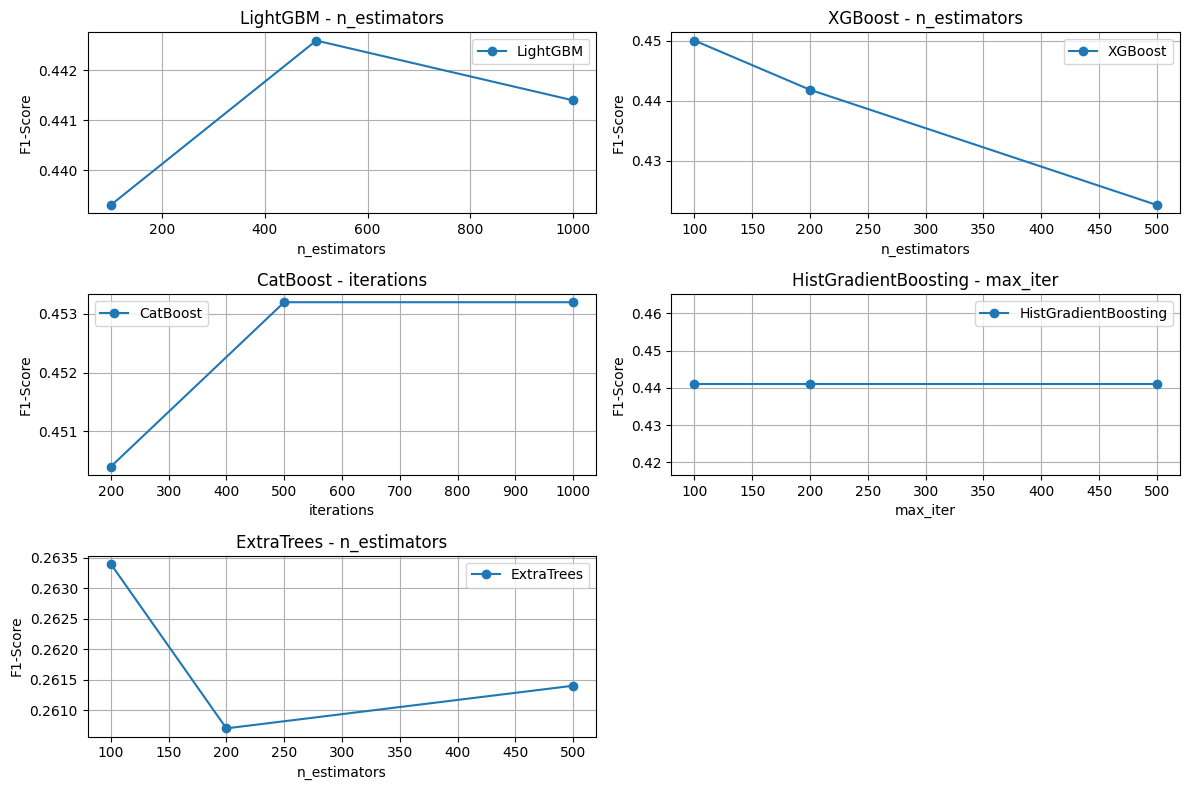

In [2]:
# Données des F1-Scores par modèle et hyperparamètre
results = {
    "LightGBM": {"n_estimators": [100, 500, 1000], "F1": [0.4393, 0.4426, 0.4414]},
    "XGBoost": {"n_estimators": [100, 200, 500], "F1": [0.4500, 0.4418, 0.4226]},
    "CatBoost": {"iterations": [200, 500, 1000], "F1": [0.4504, 0.4532, 0.4532]},
    "HistGradientBoosting": {
        "max_iter": [100, 200, 500],
        "F1": [0.4409, 0.4409, 0.4409],
    },
    "ExtraTrees": {"n_estimators": [100, 200, 500], "F1": [0.2634, 0.2607, 0.2614]},
}

# Création des graphes
plt.figure(figsize=(12, 8))
for i, (model, data) in enumerate(results.items(), start=1):
    plt.subplot(3, 2, i)
    plt.plot(data[list(data.keys())[0]], data["F1"], marker="o", label=model)
    plt.title(f"{model} - {list(data.keys())[0]}")
    plt.xlabel(list(data.keys())[0])
    plt.ylabel("F1-Score")
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

L'analyse des hyperparamètres liés au nombre d'estimators et aux itérations montre des variations intéressantes selon les modèles.

* LightGBM et CatBoost bénéficient d'un nombre moyen d'estimateurs ou d'itérations (500).
* XGBoost atteint ses meilleures performances rapidement avec un faible nombre d'estimateurs.
* Les modèles comme HistGradientBoosting montrent une stabilité qui pourrait refléter une limite inhérente des performances dans ce cas précis.
* Pour ExtraTrees, les performances restent faibles dans toutes les configurations testées, ce qui pourrait nécessiter une exploration plus approfondie des autres hyperparamètres.

### Utilisation des modèles optimaux

L'ensemble des hyperparamètres définis pour les modèles (LightGBM, XGBoost, CatBoost, HistGradientBoosting et ExtraTrees) a été déterminé à l'aide de GridSearchCV. Cette méthode effectue une recherche systématique des meilleures combinaisons d'hyperparamètres en évaluant les performances sur un ensemble de validation croisée. Les valeurs finales reflètent les réglages optimaux pour maximiser la performance des modèles tout en prenant en compte l'équilibre des classes et les contraintes spécifiques des données.

In [18]:
lgbm_clf = LGBMClassifier(
    random_state=42,
    force_row_wise=True,
    class_weight="balanced",
    verbosity=-1,
    objective="binary",
    learning_rate=0.05,
    max_depth=20,
    n_estimators=500,
    num_leaves=100,
    subsample=0.5,
    reg_alpha=1,
)

xgb_clf = XGBClassifier(
    scale_pos_weight=3.0,
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    subsample=1.0,
    eval_metric="logloss",
    random_state=42,
)

catboost_clf = CatBoostClassifier(
    class_weights=[1, 2.5],
    iterations=500,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    eval_metric="Logloss",
    verbose=0,
)

hist_gb_clf = HistGradientBoostingClassifier(
    class_weight="balanced",
    learning_rate=0.1,
    max_iter=200,
    max_depth=5,
    min_samples_leaf=30,
    random_state=42,
)

extra_trees_clf = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42,
    class_weight="balanced",
)

# Création de l'ensemble (VotingClassifier)
ensemble_model = VotingClassifier(
    estimators=[
        ("lightgbm", lgbm_clf),
        ("xgboost", xgb_clf),
        ("catboost", catboost_clf),
        ("hist_gradient_boosting", hist_gb_clf),
        ("extra_trees", extra_trees_clf),
    ],
    voting="soft",
    weights=[1, 1.95, 2.15, 1.05, 1],
)

In [19]:
# Liste des modèles individuels
models = {
    "lightgbm": lgbm_clf,
    "xgboost": xgb_clf,
    "catboost": catboost_clf,
    "hist_gradient_boosting": hist_gb_clf,
    "extra_trees": extra_trees_clf,
}

# Entraîner et tester chaque modèle individuellement
for model_name, model in models.items():
    print(f"\n=== Entraînement du modèle : {model_name} ===")
    model_copy = deepcopy(model)
    model_copy.fit(X_resampled, y_resampled.values.ravel())

    y_test_pred = model_copy.predict(X_test)
    print(f"\nÉvaluation de {model_name} sur l'ensemble de test :")
    print(confusion_matrix(y_test, y_test_pred))
    print("F1 Score:", f1_score(y_test, y_test_pred))
    del model_copy

# Entraîner et tester l'ensemble (VotingClassifier)
print("\n=== Entraînement de l'ensemble (VotingClassifier) ===")
ensemble_model.fit(X_resampled, y_resampled.values.ravel())

y_test_pred = ensemble_model.predict(X_test)
print("\nÉvaluation de l'ensemble sur l'ensemble de test :")
print(confusion_matrix(y_test, y_test_pred))
print("F1 Score:", f1_score(y_test, y_test_pred))


=== Entraînement du modèle : lightgbm ===

Évaluation de lightgbm sur l'ensemble de test :
[[26497  8432]
 [ 1594  4066]]
F1 Score: 0.44784667914968607

=== Entraînement du modèle : xgboost ===

Évaluation de xgboost sur l'ensemble de test :
[[28988  5941]
 [ 2159  3501]]
F1 Score: 0.4636471990464839

=== Entraînement du modèle : catboost ===

Évaluation de catboost sur l'ensemble de test :
[[30230  4699]
 [ 2570  3090]]
F1 Score: 0.45951371849208117

=== Entraînement du modèle : hist_gradient_boosting ===

Évaluation de hist_gradient_boosting sur l'ensemble de test :
[[24793 10136]
 [ 1196  4464]]
F1 Score: 0.44067127344521223

=== Entraînement du modèle : extra_trees ===

Évaluation de extra_trees sur l'ensemble de test :
[[33975   954]
 [ 4657  1003]]
F1 Score: 0.26335827753708807

=== Entraînement de l'ensemble (VotingClassifier) ===

Évaluation de l'ensemble sur l'ensemble de test :
[[29489  5440]
 [ 2260  3400]]
F1 Score: 0.4689655172413793


## Prédiction


Meilleur seuil basé sur le F1 score : 0.5040000000000002
Meilleur F1 Score : 0.4699248120300752

Matrice de confusion au seuil optimal :
[[29600  5329]
 [ 2285  3375]]


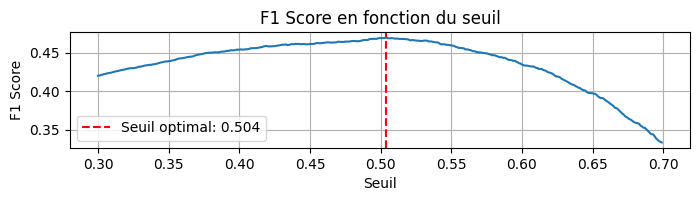

In [20]:
# Analyse des seuils pour le VotingClassifier
y_test_pred_proba = ensemble_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.3, 0.7, 0.001)  # Différents seuils
f1_scores = [f1_score(y_test, (y_test_pred_proba >= t).astype(int)) for t in thresholds]

# Trouver le seuil optimal basé sur le F1 score
best_threshold = thresholds[np.argmax(f1_scores)]
print("\nMeilleur seuil basé sur le F1 score :", best_threshold)
print("Meilleur F1 Score :", max(f1_scores))

# Prédictions au seuil optimal
y_test_pred_optimal = (y_test_pred_proba >= best_threshold).astype(int)

# Matrice de confusion au seuil optimal
conf_matrix = confusion_matrix(y_test, y_test_pred_optimal)
print("\nMatrice de confusion au seuil optimal :")
print(conf_matrix)

# Visualisation des F1 scores en fonction des seuils
plt.figure(figsize=(8, 1.5))
plt.plot(thresholds, f1_scores)
plt.axvline(
    x=best_threshold,
    color="r",
    linestyle="--",
    label=f"Seuil optimal: {best_threshold:.3f}",
)
plt.title("F1 Score en fonction du seuil")
plt.xlabel("Seuil")
plt.ylabel("F1 Score")
plt.grid(True)
plt.legend()
plt.show()

## Soumission Kaggle

La soumission de kaggle est fait avec le modèle d'ensemble avec le meilleur de probabilité pour avoir un bon résultat.

In [21]:
data_test = pd.read_csv('data/test.csv')

test_index = data_test["Unnamed: 0"]
data_test = data_test.drop(columns=["Unnamed: 0"])

df_data_test_copy = pretraitement(data_test, None)
scaler_test = StandardScaler()

df_data_test_copy = scaler.transform(
    df_data_test_copy
)
y_pred_test_proba = ensemble_model.predict_proba(df_data_test_copy)[:, 1]
y_pred_test = (y_pred_test_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    "index": test_index,  
    "Diabetes_binary": y_pred_test
})

submission.to_csv("soumission.csv", index=False)